In [131]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [132]:
df = pd.read_csv("winequality-red.csv",sep=';')

In [133]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [134]:
# Here we define X and Y (explanatory variables and dependent variable)
X = df.drop(columns=["quality"])
y = df["quality"]

In [135]:
# Computation of the correlation matrix
corr_matrix = df.corr()
print(corr_matrix)

                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.256131     0.671703   
volatile acidity          -0.256131          1.000000    -0.552496   
citric acid                0.671703         -0.552496     1.000000   
residual sugar             0.114777          0.001918     0.143577   
chlorides                  0.093705          0.061298     0.203823   
free sulfur dioxide       -0.153794         -0.010504    -0.060978   
total sulfur dioxide      -0.113181          0.076470     0.035533   
density                    0.668047          0.022026     0.364947   
pH                        -0.682978          0.234937    -0.541904   
sulphates                  0.183006         -0.260987     0.312770   
alcohol                   -0.061668         -0.202288     0.109903   
quality                    0.124052         -0.390558     0.226373   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity    

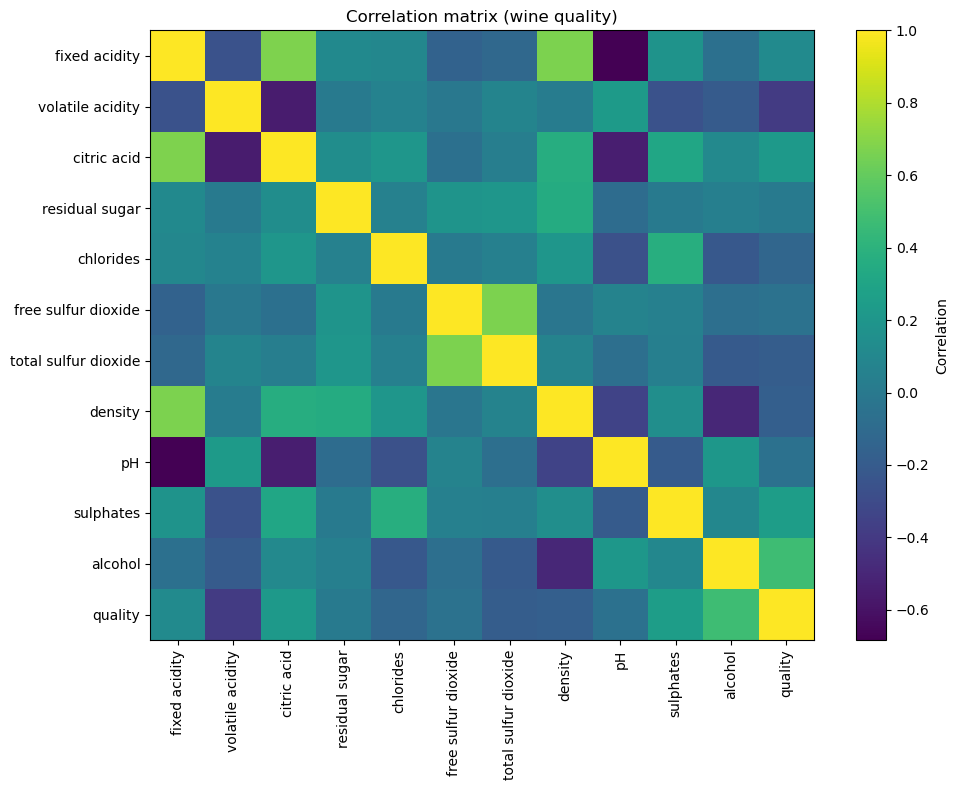

In [148]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
plt.imshow(corr.values, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation matrix (wine quality)")
plt.tight_layout()
plt.show()

In [136]:
# Here we split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [137]:
# define the cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# componant grid
max_components = min(X_train.shape[1], X_train.shape[0] - 1)
components_grid = np.arange(1, max_components + 1)

In [144]:
# -----------------------
# PCR (PCA + OLS)
# -----------------------
# standarisation of variables , PCA transform the variables into component 
#and then we predict the quality from these componants 

pipe_pcr = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("reg", LinearRegression())
])
# Here we test all possible k and choose the k that minimizes RMSE in cross-validation
grid_pcr = GridSearchCV(
    estimator=pipe_pcr,
    param_grid={"pca__n_components": components_grid},
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_pcr.fit(X_train, y_train)

best_pcr = grid_pcr.best_estimator_
best_k_pcr = grid_pcr.best_params_["pca__n_components"]
best_rmse_cv_pcr = -grid_pcr.best_score_

y_pred_pcr = best_pcr.predict(X_test)
rmse_pcr = np.sqrt(mean_squared_error(y_test, y_pred_pcr))
mae_pcr = mean_absolute_error(y_test, y_pred_pcr)
r2_pcr = r2_score(y_test, y_pred_pcr)

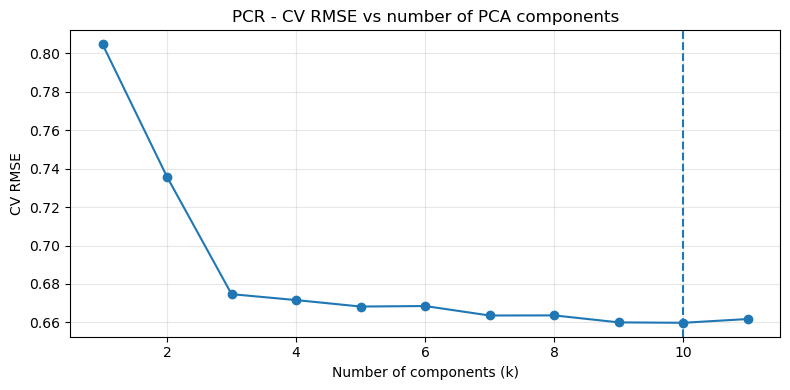

In [149]:
# Graph
k_pcr = grid_pcr.cv_results_["param_pca__n_components"].data.astype(int)
rmse_pcr_cv = -grid_pcr.cv_results_["mean_test_score"]  # because neg RMSE

plt.figure(figsize=(8,4))
plt.plot(k_pcr, rmse_pcr_cv, marker="o")
plt.axvline(best_k_pcr, linestyle="--")
plt.title("PCR - CV RMSE vs number of PCA components")
plt.xlabel("Number of components (k)")
plt.ylabel("CV RMSE")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [145]:
# -----------------------
# PLS
# -----------------------
# Here we do the same like in part of PCR 
pipe_pls = Pipeline([
    ("scaler", StandardScaler()),
    ("pls", PLSRegression())
])

grid_pls = GridSearchCV(
    estimator=pipe_pls,
    param_grid={"pls__n_components": components_grid},
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_pls.fit(X_train, y_train)

best_pls = grid_pls.best_estimator_
best_k_pls = grid_pls.best_params_["pls__n_components"]
best_rmse_cv_pls = -grid_pls.best_score_

y_pred_pls = best_pls.predict(X_test).ravel()
rmse_pls = np.sqrt(mean_squared_error(y_test, y_pred_pls))
mae_pls = mean_absolute_error(y_test, y_pred_pls)
r2_pls = r2_score(y_test, y_pred_pls)

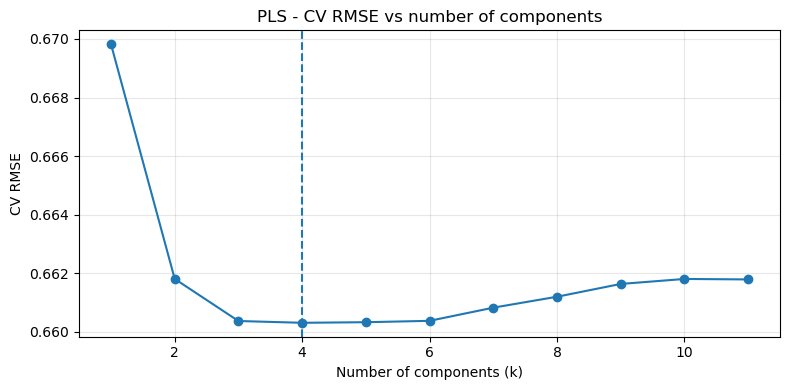

In [150]:
# Graph
k_pls = grid_pls.cv_results_["param_pls__n_components"].data.astype(int)
rmse_pls_cv = -grid_pls.cv_results_["mean_test_score"]

plt.figure(figsize=(8,4))
plt.plot(k_pls, rmse_pls_cv, marker="o")
plt.axvline(best_k_pls, linestyle="--")
plt.title("PLS - CV RMSE vs number of components")
plt.xlabel("Number of components (k)")
plt.ylabel("CV RMSE")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [147]:
# -----------------------
# Results table
# -----------------------
results = pd.DataFrame({
    "Method": ["PCR (PCA + OLS)", "PLS"],
    "Best k (CV)": [best_k_pcr, best_k_pls],
    "Best CV RMSE": [best_rmse_cv_pcr, best_rmse_cv_pls],
    "Test RMSE": [rmse_pcr, rmse_pls],
    "Test MAE": [mae_pcr, mae_pls],
    "Test R²": [r2_pcr, r2_pls]
})

(results)

,Method,Best k (CV),Best CV RMSE,Test RMSE,Test MAE,Test R²
0,PCR (PCA + OLS),10,0.659827,0.624063,0.503366,0.404053
1,PLS,4,0.660305,0.625388,0.502767,0.401520


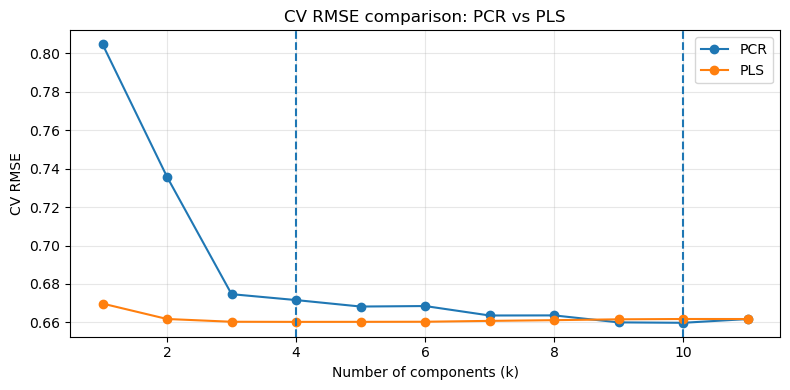

In [151]:
plt.figure(figsize=(8,4))
plt.plot(k_pcr, rmse_pcr_cv, marker="o", label="PCR")
plt.plot(k_pls, rmse_pls_cv, marker="o", label="PLS")
plt.axvline(best_k_pcr, linestyle="--")
plt.axvline(best_k_pls, linestyle="--")
plt.title("CV RMSE comparison: PCR vs PLS")
plt.xlabel("Number of components (k)")
plt.ylabel("CV RMSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [154]:
plt.savefig("corr_heatmap.png", dpi=300, bbox_inches="tight")
plt.savefig("rmse_pcr_vs_k.png", dpi=300, bbox_inches="tight")
plt.savefig("rmse_pls_vs_k.png", dpi=300, bbox_inches="tight")
plt.savefig("rmse_comparison_pcr_pls.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>